# **Approssimazione numerica di integrali**

## Formule di quadratura (approssimazione di integrali)

Le formule di quadratura sono tecniche numeriche volte ad approssimare integrali del tipo

$$\int_{a}^{b}f(s)ds$$

per mezzo di valutazioni *puntuali* dell'integranda $f$. In altre parole, una volta fissata un opportuna griglia $\{x_{0} < x_{1} < \dots < x_{n}\}\subset[a,b]$, l'idea è quella di combinare in maniera opportuna i valori $\{(x_{i}, f(x_{i}))\}$ per approssimare l'integrale in questione. Molto spesso, queste formule vengono costruire rimpiazzando $f$ con opportune interpolanti/approssimanti il cui integrale sia facile da calcolare.

In quanto segue, assumiamo di utilizzare una griglia uniforme di passo $h>0$.
</br></br>
In questo laboratorio ci occuperemo dell'approssimazione numerica di integrali tramite formule di quadratura composite.

# Esercizio 1

Si consideri il seguente integrale $I$:

\begin{equation}
I = \int_0^1 x^2 dx.
\end{equation}

Si voglio confrontare diverse formule di quadratura composite per il calcolo di $I$.

<mark>**Esercizio 1.1**</mark></br>
Scrivere tre funzioni, chiamate *pmedcomp*, *trapcomp* e *simpcomp*, che implementano rispettivamente le formule di quadratura composite del punto medio, del trapezio e di Simpson su intervalli equispaziati.
Tali funzioni dovranno ricevere in ingresso gli estremi di integrazione $a$ e $b$, il numero di sottointervalli $N$ in cui si vuole suddividere il dominio di integrazione, e la funzione $f$ da integrare; in uscita, dovranno restituire il valore approssimato dell'integrale.

In [4]:
import numpy as np

In [10]:
#Le seguenti funzioni restituiscono l'integrale che approssima la funzione f
#punto medio composito
def pmedcomp(f, a, b, N):
    h=(b-a)/N
    x=np.linspace(a, b, N+1) #N sottointervalli -> N+1 nodi della griglia
    xL=x[:-1] #tutti i nodi escluso l'ultimo (xn=b)
    xR=x[1:] #tutti i nodi escluso il primo (x0=a)
    xM=(xL+xR)/2
    I=h*f(xM).sum()
    return I

#trapezi composito
def trapcomp(f, a, b, N):
    h=(b-a)/N
    x=np.linspace(a, b, N+1)
    xL=x[:-1]
    xR=x[1:]
    I=0.5*h*(f(xL)+f(xR)).sum()
    return I

#simpson composito
def simpcomp(f, a, b, N):
    h=(b-a)/N
    x=np.linspace(a, b, N+1)
    xL=x[:-1]
    xR=x[1:]
    xM=(xL+xR)/2
    I=(h/6)*(f(xL)+4*f(xM)+f(xR)).sum()
    return I

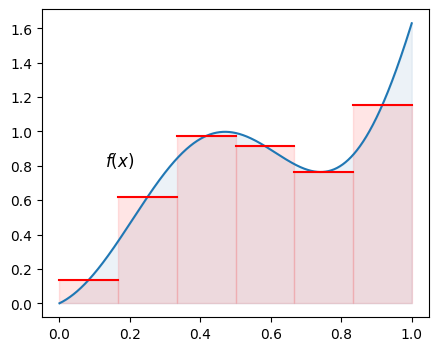

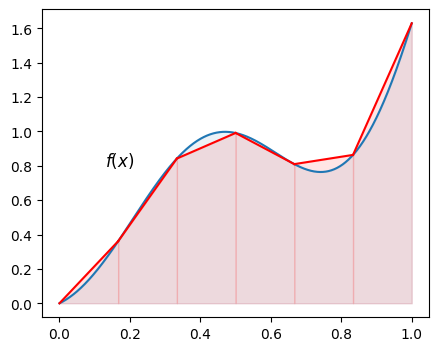

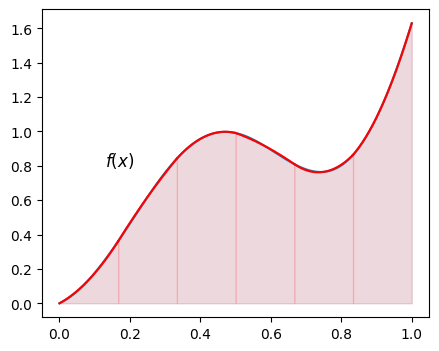

In [2]:
from niceplots import show
show("Punto medio")
show("Trapezi")
show("Simpson")


### Metodo del punto medio (composito)

$$\int_{a}^{b}f(s)ds\approx \sum_{i=0}^{n-1}f\left(\frac{x_{i}+x_{i+1}}{2}\right)(x_{i+1}-x_{i})=h\sum_{i=0}^{n-1}f\left(x_{i}+\frac{h}{2}\right).$$

Geometricamente parlando, si sta approssimando l'area sottesa da $f$ con una serie di rettangoli (equivalentemente, stiamo sostituendo $f$ con una sua approssimazione **costante a tratti**).

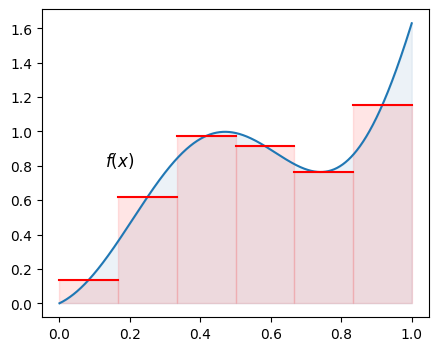

In [3]:
from niceplots import show
show("Punto medio")

In [ ]:
def pmedcomp(f, a, b, N):
  """
  Formula del punto medio composita
  Input:
     f:   funzione da integrare
     a:   estremo sinistro dell'intervallo di integrazione
     b:   estremo destro dell'intervallo di integrazione
     N:   numero di sottointervalli (N = 1 formula di integrazione semplice)
  Output:
     I:   integrale approssimato
  """
  #ampiezza di ciascun sottoi-intervallo
  h=(b-a)/N
  #griglia di punti
  x=np.linspace(a, b, N+1)

  #vettore degli estremi sinistri (left -> L) di ciascun sotto-intervallo
  xL=x[:-1] #estraggo dal vettore x tutti i nodi a partire dal primo fino all'ultimo escluso (x0=a fino a x(n-1), ossia il nodo prima di b=x(n))

  #vettore degli estremi destri (right -> R)
  xR=x[1:] #estraggo dal vettore x tutti i nodi escluso il primo, fino all'ultimo incluso
  #si possono combinare xL e xR per creare il vettore dei punti medi
  xM=(xL+xR)/2 #si sommano punto a punto/componente a componente i due vettori e si divide per due, così da trovare
  #tutti i punti medi di ciascun sotto-intervallo

  #calcolo integrale (punto medio)
  I=h*f(xM).sum() #array.sum()  calcola la somma di tutte le sue componenti nel np.array

  return I


### Metodo dei trapezi (composito)

$$\int_{a}^{b}f(s)ds\approx \sum_{i=0}^{n-1}\frac{1}{2}\Big[f(x_{i})+f(x_{i+1})\Big](x_{i+1}-x_{i})=\frac{h}{2}\sum_{i=0}^{n-1}\Big[f(x_{i})+f(x_{i+1})\Big].$$

Geometricamente parlando, si sta approssimando l'area sottesa da $f$ con una serie di trapezi (equivalentemente, stiamo sostituendo $f$ con una sua approssimazione **lineare a tratti**).

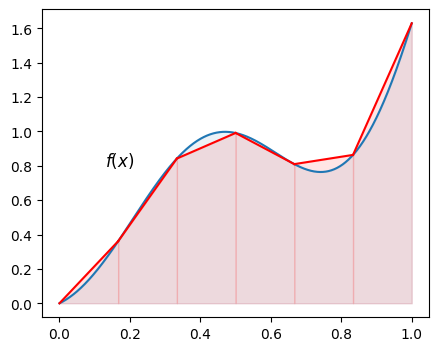

In [ ]:
show("Trapezi") #sfrutta ancora niceplots e rappresente/restituisce il metodo di approssimazione dei trapezi

In [ ]:
def trapcomp(f, a, b, N):
  """
  Formula dei trapezi composita
  Input:
     f:   funzione da integrare
     a:   estremo sinistro dell'intervallo di integrazione
     b:   estremo destro dell'intervallo di integrazione
     N:   numero di sottointervalli (N = 1 formula di integrazione semplice)
  Output:
     I:   integrale approssimato
  """
  #ampiezza di ciascun sotto-intervallo
  h=(b-a)/N
  #griglia di punti
  x=np.linspace(a, b, N+1)

  #vettore degli estremi sinistri (left -> L) di ciascun sotto-intervallo (T=trapezi)
  xL_T=x[:-1] 
  #vettore degli estremi destri (right -> R)
  xR_T=x[1:]
  
  #calcolo integrale (punto medio)
  I=h/2*(f(xL_T)+f(xR_T)).sum() #array.sum() calcola la somma di tutte le sue componenti nel np.array
  return I


### Metodo di Cavalieri-Simpson (composito)

$$\int_{a}^{b}f(s)ds\approx \frac{h}{6}\sum_{i=0}^{n-1}\left[f(x_{i})+4f\left(\frac{x_{i}+x_{i+1}}{2}\right)+f(x_{i+1})\right].$$

Geometricamente parlando, si sta approssimando l'area sottesa da $f$ con una serie di "sotto parabole" (equivalentemente, stiamo sostituendo $f$ con una sua approssimazione **quadratica a tratti**).

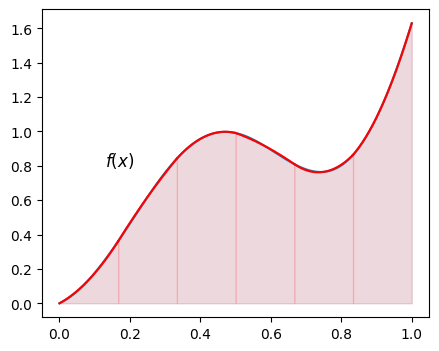

In [6]:
show("Simpson")

In [ ]:
def simpcomp(f, a, b, N):
  """
  Formula di Cavalieri-Simpson composita
  Input:
     f:   funzione da integrare
     a:   estremo sinistro dell'intervallo di integrazione
     b:   estremo sinistro dell'intervallo di integrazione
     N:   numero di sottointervalli (N = 1 formula di integrazione semplice)
  Output:
     I:   integrale approssimato
  """
  #ampiezza di ciascun sotto-intervallo
  h=(b-a)/N
  #griglia di punti
  x=np.linspace(a, b, N+1)

  #vettore degli estremi sinistri (left -> L) di ciascun sotto-intervallo (S=Simpson)
  xL_S=x[:-1] 
  #vettore degli estremi destri (right -> R)
  xR_S=x[1:]
  #si possono combinare xL e xR per creare il vettore 
  xM_S=(xL_S+xR_S)/2
  
  #calcolo integrale (punto medio)
  I=h/6*(f(xL_S)+4*f(xM_S)+f(xR_S)).sum() #array.sum() calcola la somma di tutte le sue componenti nel np.array
  return I


<mark>**Esercizio 1.2**</mark></br>
Utilizzando le funzioni definite all'Esercizio 1.1, approssimare il valore dell'integrale $I$ usando $N=20$ sottointervalli. Calcolare quindi analiticamente (a mano) il vero valore dell'integrale e confrontarlo con le approssimazioni ottenute. Cosa si osserva? Commentare opportunamente il risultato ottenuto.

In [17]:
f=lambda x: x**2
N=20
a=0
b=1
#formule di quadratura per l'approssimazione dell'integrale di f
I_pm=pmedcomp(f, a, b, N)
I_t=trapcomp(f, a, b, N)
I_s=simpcomp(f, a, b, N)

I_ex=1/3

#errori assoluti tra interpolante e integrale esatto
err_pm=np.abs(I_ex-I_pm)
err_t=np.abs(I_ex-I_t)
err_s=np.abs(I_ex-I_s)

print("Gli errori di integrazione/quadratura composita per punto medio, trapezi e simpson sono: \n", err_pm, err_t, err_s)









Gli errori di integrazione/quadratura composita per punto medio, trapezi e simpson sono: 
 0.00020833333333319937 0.0004166666666667873 0.0


In [ ]:
# Definizione dell'integranda e dei parametri dell'esercizio
f = lambda x: x**2
a, b = 0, 1
N = 20

# Integrali approssimati
I_pmc=pmedcomp(f, a, b, N) #metodo punto medio composito
I_tc=trapcomp(f, a, b, N) #metodo trapezi composito
I_sc=simpcomp(f, a, b, N) #metodo simpson composito

# Integrale esatto
I_ex=1/3


# Calcolo degli errori
err_pmc=abs(I_ex-I_pmc)
err_tc=abs(I_ex-I_tc)
err_sc=abs(I_ex-I_sc)

print("Errori assoluti\n"+"-"*28)
print("Punto medio\t%e" % err_pmc)
print("Trapezi\t\t%e" % err_tc)
print("Simpson\t\t%e" % err_sc)

Errori assoluti
----------------------------
Punto medio	2.083333e-04
Trapezi		4.166667e-04
Simpson		0.000000e+00


In [ ]:
#la formula di quadratura di simpson composito dà errore esattamente nullo dal momento che ha grado di esattezza 3; invece, sia punto medio sua
#trapezi compositi hanno grado di esattezza 1, quindi NON approssimo in modo esatto l'integrale esatto. 

<mark>**Domanda**</mark></br>
Quale è il grado di esattezza delle formule di quadratura implementate? I risultati ottenuti confermano quello che sappiamo dalla teoria?
<br><br>
Si ricordano di seguito le stime dell'errore commesso dalle tre formule di quadratura implementate:

\begin{equation}
\nonumber
E_{PM}^c \le \frac{b-a}{24} \cdot h^2 \cdot ||f^{(ii)}||_\infty
\end{equation}

\begin{equation}
\nonumber
E_{T}^c \le \frac{b-a}{12} \cdot h^2 \cdot ||f^{(ii)}||_\infty
\end{equation}

\begin{equation}
\nonumber
E_{CS}^c \le \frac{b-a}{16\cdot180} \cdot h^4 \cdot ||f^{(iv)}||_\infty
\end{equation}

In [ ]:
#i gradi di esattezza delle formule di quadratura composite sono: per punto medio e trapezi pari a 1 (ossia si riescono a integrare
#esattamente funzioni lineari e costanti) mentre per simpson pari a 3 (ossia si riescono a integrare esattamente funzioni fino al grado 3). Il
#grado di accuratezza, invece, pari all'esponente di h che determina l'andamento dell'errore del metodo di quadratura, è:
#per punto medio e trapezi pari a 2 (l'errore ha decremento quadratico), mentre per simpson pari a 4.

# Esercizio 2

Si consideri il seguente integrale,

$$ I = \int_0^1 x^5\sin(\pi x)dx,$$

il cui valore esatto è $(120-20\pi^2+\pi^4)/\pi^5.$

<mark>**Esercizio 2.1**</mark></br>

Si calcolino gli errori associati alle tre formule di quadratura (punto medio, trapezi, Cavalieri-Simpson) per il calcolo dell'integrale $I$, all'aumentare del numero di sottointervalli: $N=5, 10, 20, 40, 80$ ($N=5\cdot2^k, k=0,...,4$), o in altre parole, al dimezzarsi dell'ampiezza $h$ dei sottointervalli. Si verifichino poi gli ordini di convergenza previsti dalla teoria per le tre formule di quadratura rappresentando gli errori in un grafico opportuno. Si commentino i risultati.
<br><br>
Si ricordano di seguito le stime dell'errore commesso dalle tre formule di quadratura implementate:

\begin{equation}
\nonumber
\begin{aligned}
E_{PM}^c &\le \frac{b-a}{24} \cdot h^2 \cdot ||f^{(ii)}||_\infty \simeq Ch^2 \\
E_{T}^c &\le \frac{b-a}{12} \cdot h^2 \cdot ||f^{(ii)}||_\infty \simeq Ch^2\\
E_{CS}^c &\le \frac{b-a}{16\cdot180} \cdot h^4 \cdot ||f^{(iv)}||_\infty \simeq Ch^4
\end{aligned}
\end{equation}

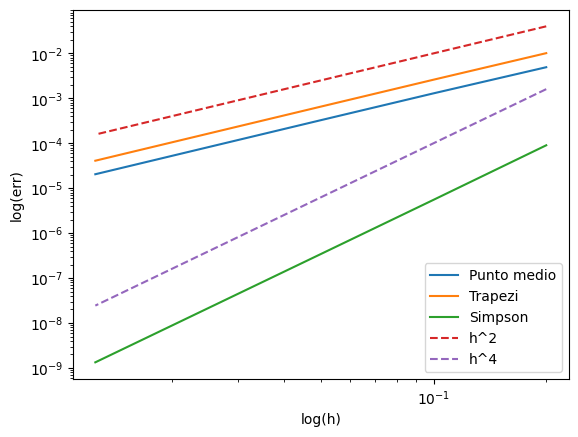

In [ ]:
import matplotlib.pyplot as plt
f=lambda x: x**5*np.sin(np.pi*x)
a=0
b=1
N_list=[5, 10, 20, 40, 80]
I_ex=(120-20*np.pi**2+np.pi**4)/np.pi**5

h=[]

err_pm=[]
err_t=[]
err_s=[]

for N in N_list:
    h.append((b-a)/N)

    I_pm=pmedcomp(f, a, b, N)
    I_t=trapcomp(f, a, b, N)
    I_s=simpcomp(f, a, b, N)

    err_pm.append(np.abs(I_pm-I_ex))
    err_t.append(np.abs(I_t-I_ex))
    err_s.append(np.abs(I_s-I_ex))

#verifica degli ordini di convergenza
h=np.array(h)
plt.figure()
plt.loglog(h, err_pm, label="Punto medio")
plt.loglog(h, err_t, label="Trapezi")
plt.loglog(h, err_s, label="Simpson")
#realizzo il grafico anche degli andamenti teorici quadratici e alla quarta per l'errore dei metodi di quadratura
plt.loglog(h, h**2, '--', label="h^2")
plt.loglog(h, h**4, '--', label="h^4")

plt.xlabel("log(h)")
plt.ylabel("log(err)")
plt.legend()
plt.show()

#ho usato in autonomia un altro modo, differente da quello dei dizionari spiegato sotto per risolvere il problema


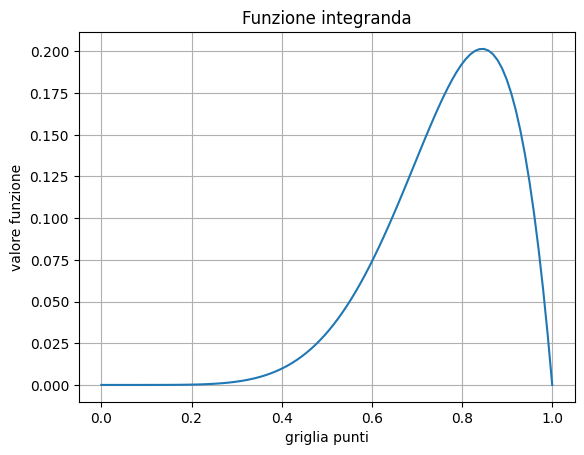

In [ ]:
import matplotlib.pyplot as plt
from numpy import pi, sin

# Definisco l'integranda e i parametri dell'esercizio
f=lambda x: x**5*np.sin(np.pi*x)
a=0
b=1

x_grid=np.linspace(a, b, 100)

# Rappresento la funzione
plt.figure()
plt.plot(x_grid, f(x_grid))
plt.title("Funzione integranda")
plt.xlabel("griglia punti")
plt.ylabel("valore funzione")
plt.grid()
plt.show()

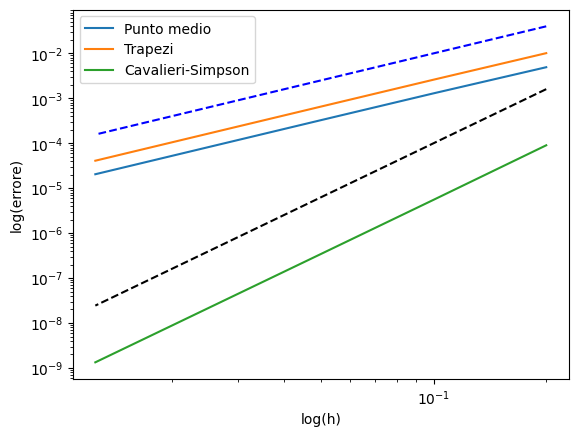

In [ ]:
# Valore esatto dell'integrale
I_ex = (120-20*pi**2 + pi**4)/(pi**5)

# Inizializzo un "dizionario" per gestire gli errori -> si veda sotto l'Approfondimento
err = {'Punto medio': [], 'Trapezi': [], 'Cavalieri-Simpson': []} #creo tre liste vuote a cui poi posso andare
#ad aggiungere elementi pari agli errori calcolati con le varie formule composite

# Calcolo gli errori al variare del numero di suddivisioni dell'intervallo
N_vect = [5, 10, 20, 40, 80]
h=[]

#modo 1
#for k in range(5):
#    N=int(5*(2**k)) #aggiungo int poiché N deve essere un intero

#modo 2
for N in N_vect:
    h.append((b-a)/N)
    err['Punto medio'].append(abs(I_ex-pmedcomp(f, a, b, N)))
    err['Trapezi'].append(abs(I_ex-trapcomp(f, a, b, N)))
    err['Cavalieri-Simpson'].append(abs(I_ex-simpcomp(f, a, b, N)))


# Verifico l'ordine di convergenza
plt.figure()

for metodo in err.keys(): #err.keys() assume i valori, uno dopo l'altro, di Punto medio, Trapezio e Simpson
    plt.loglog(h, err[metodo], label=metodo)

h=np.array(h) #converto h da una lista a un array, così che posso rappresentare nel plot le rette di riferimento

plt.loglog(h, h**2, 'b--')
plt.loglog(h, h**4, 'k--')
plt.xlabel('log(h)')
plt.ylabel('log(errore)')
plt.legend()
plt.show()

#si usa il grafico doppio-logaritmico in quanto emerge molto bene la pendenza del grafico, che corrisponde all'ordine/
#grado di convergenza (P) -> dal grafico, punto medio e trapezio sono rette con pendenza 2, mentre simpson ha pendenza 4, come
#emerge dal confronto con le rette di riferimento tratteggiate


<mark>**Domanda**</mark></br>
Quale è l'ordine di accuratezza delle formule di quadratura implementate? I risultati ottenuti confermano quello che sappiamo dalla teoria? Perchè la scelta migliore è quella di utilizzare un grafico loglog per rappresentare l'errore?

**Commento**

Osserviamo che i metodi del Punto medio e dei Trapezi sono di ordine 2. Invece, il metodo di Cavalieri-Simpson è di ordine 4. L'ordine di accuratezza è in perfetto accordo con le stime teoriche.

In [ ]:
#la scelta migliore è impiegare dei grafici doppio-logaritmici (base 10) in quanto emerge molto chiaramente la pendenza delle rette
#rappresentanti l'errore del metodo di quadratura considerato, pari all'ordine di accuratezza del metodo stesso (hanno andamento lineare
#con pendenze differenti, facilmente confrontabili con rette costruite apposta, in scala logaritmica).

# Approfondimento: i dizionari in python

La soluzione proposta fa uso dei cosìdetti *dizionari*, oggetti simili alle liste ma che si distinguono per l'utilizzo di etichette (dette *chiavi*), al posto dei classici indici posizionali. Ovviamente, non è necessario utilizzare i dizionari per risolvere l'esercizio, si tratta solo di una piccola aggiunta volta ad espandere la vostra conoscenza del linguaggio.

La chiamata

    carrello = {'banane':5, 'mele':4, 'pere':8}

definisce un dizionario, le cui *chiavi* sono le stringhe 'banane', 'mele' e 'pere'. Queste etichette, si possono utilizzare per accedere agli elementi corrispondenti. Per esempio,

    carrello['banane']

restituisce 5, che è il valore corrispondente. In generale, il contenuto di un dizionario può essere qualsiasi: qui, gli elementi sono numeri interi, nell'esercizio, invece, gli elementi sono liste (liste di errori, una per ogni metodo).

L'elenco delle chiavi in un dizionario si può estrarre con il metodo ".keys()"

    carrello.keys()

che qui restituisce un iterabile (sostanzialmente una lista) contenente 'banane', 'mele' e 'pere'.